In [14]:
# %%
from pathlib import Path
import sys
import os
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr

REPO_ROOT = Path.cwd().parents[1]  # falls Notebook in notebooks/... liegt
DATA_PATH = REPO_ROOT / "data" / "all_heuristics_dataset.pkl"

# ---- Clean run naming ----
PROVIDER = "ollama"
MODEL = os.getenv("OLLAMA_MODEL", "qwen2.5:7b").replace(":", "_").replace("/", "_")
RUN_TAG = time.strftime("%Y%m%d_%H%M%S")

OUT_DIR = REPO_ROOT / "data" / "outputs" / f"ppp_global__{PROVIDER}__{MODEL}__{RUN_TAG}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PPP_TEMPLATE_PATH = REPO_ROOT / "src" / "prompt_templates" / "ppp_with_refs.md"

print("REPO_ROOT:", REPO_ROOT)
print("DATA_PATH exists:", DATA_PATH.exists(), DATA_PATH)
print("OUT_DIR:", OUT_DIR)
print("PPP_TEMPLATE_PATH exists:", PPP_TEMPLATE_PATH.exists(), PPP_TEMPLATE_PATH)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("sys.path[0]:", sys.path[0])


REPO_ROOT: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction
DATA_PATH exists: True c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\all_heuristics_dataset.pkl
OUT_DIR: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_global__ollama__qwen2.5_7b__20260215_185047
PPP_TEMPLATE_PATH exists: True c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\src\prompt_templates\ppp_with_refs.md
sys.path[0]: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction


In [15]:
# %%
import os
from dataclasses import dataclass
from openai import OpenAI

# Ollama local OpenAI-compatible endpoint
base_url = "http://localhost:11434/v1"
model = os.getenv("OLLAMA_MODEL", "qwen2.5:7b")

# Dummy key (required by SDK, not used by Ollama)
api_key = "ollama"

oai = OpenAI(base_url=base_url, api_key=api_key)

@dataclass
class SimpleResp:
    text: str

class OllamaLLMClient:
    def __init__(self, client: OpenAI, model: str):
        self.client = client
        self.model = model

    def generate(self, prompt: str, temperature: float = 0.0, max_tokens: int = 256, meta=None):
        r = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=max_tokens,
        )
        return SimpleResp(text=r.choices[0].message.content)

client = OllamaLLMClient(oai, model)

# Preflight
resp = client.generate('Return JSON only: {"ping":"pong"}', temperature=0.0, max_tokens=30)
print(resp.text[:200])


{"ping":"pong"}


In [16]:
df = pd.read_pickle(DATA_PATH)

required = {"heuristic_id", "raw_app_type", "code", "objective"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.dropna(subset=["code", "objective"]).copy()
df["heuristic_id"] = df["heuristic_id"].astype(str)
df["raw_app_type"] = df["raw_app_type"].astype(str)
df["objective"] = pd.to_numeric(df["objective"], errors="coerce")
df = df.dropna(subset=["objective"]).reset_index(drop=True)

print("Usable rows:", len(df))
df.head(3)


Usable rows: 15507


,heuristic_id,raw_app_type,instance_scale,filename,strategy,algorithm,code,objective,task_name,parse_ok,is_timeout
0,pop_0_op_e1_n0_251224_134701,bin_greedy,results_20251224_134317_bp_online_qwen25coder3...,program_pop_0_op_e1_n0_251224_134701.json,e1,The new algorithm assigns scores based on a co...,"import numpy as np\n\ndef score(item, bins):\n...",1.51534,BinPacking,True,False
1,pop_0_op_e1_n10_251224_134701,bin_greedy,results_20251224_134317_bp_online_qwen25coder3...,program_pop_0_op_e1_n10_251224_134701.json,e1,The new algorithm calculates scores for each b...,"import numpy as np\n\ndef score(item, bins):\n...",0.32770,BinPacking,True,False
2,pop_0_op_e1_n11_251224_134701,bin_greedy,results_20251224_134317_bp_online_qwen25coder3...,program_pop_0_op_e1_n11_251224_134701.json,e1,The new algorithm calculates scores for each b...,"import numpy as np\n\ndef score(item, bins):\n...",1.51534,BinPacking,True,False


In [18]:
task_bounds = (
    df.groupby("raw_app_type")["objective"]
      .agg(["min", "max"])
      .to_dict(orient="index")
)
task_bounds


{'bin_greedy': {'min': 0.00563, 'max': 1.51534},
 'cvrp_lns': {'min': 3343425.3, 'max': 3981765.6},
 'premarshalling_astar': {'min': 0.08148, 'max': 13.9329},
 'puzzle_astar': {'min': 0.4574, 'max': 3.65888}}

In [20]:
def select_refs_stratified(df_task: pd.DataFrame, target_id: str, k: int = 5):
    df_cand = df_task[df_task["heuristic_id"] != target_id].sort_values("objective", ascending=True)
    n = len(df_cand)
    if n < k:
        return None

    if k == 3:
        idxs = [0, n // 2, n - 1]  # best, mid, worst
    elif k == 5:
        idxs = [0, n // 4, n // 2, (3 * n) // 4, n - 1]  # best, q25, mid, q75, worst
    else:
        # fallback: evenly spaced k points (includes ends)
        idxs = np.linspace(0, n - 1, k).round().astype(int).tolist()

    # unique + keep order
    seen = set()
    refs = []
    for i in idxs:
        row = df_cand.iloc[int(i)]
        hid = str(row["heuristic_id"])
        if hid not in seen:
            refs.append(row)
            seen.add(hid)

    if len(refs) < k:
        # fill from the start if duplicates collapsed (rare but possible)
        for _, row in df_cand.iterrows():
            hid = str(row["heuristic_id"])
            if hid not in seen:
                refs.append(row)
                seen.add(hid)
            if len(refs) >= k:
                break

    return refs[:k]


def build_refs_block(refs):
    lines = []
    for i, r in enumerate(refs, 1):
        lines += [
            f"{i})",
            "Heuristic code:",
            "```python",
            str(r["code"]),
            "```",
            f"Objective: {float(r['objective'])}",
            ""
        ]
    return "\n".join(lines).strip() + "\n"


In [21]:
ppp_template = PPP_TEMPLATE_PATH.read_text(encoding="utf-8")

def render_ppp_prompt(*, raw_app_type, task_min, task_max, references_block, target_code):
    return ppp_template.format(
        raw_app_type=raw_app_type,
        task_min=task_min,
        task_max=task_max,
        references_block=references_block,
        target_code=target_code,
    )

print("Template loaded, length:", len(ppp_template))


Template loaded, length: 752


In [26]:
from src.api.parse import parse_ppp_response


In [12]:
TEST_PER_TASK = 3

for app, df_task in df.groupby("raw_app_type"):
    task_min = task_bounds[app]["min"]
    task_max = task_bounds[app]["max"]

    print("\n=== APP:", app, "| rows:", len(df_task), "| range:", (task_min, task_max))
    df_small = df_task.head(TEST_PER_TASK)

    for _, row in df_small.iterrows():
        hid = row["heuristic_id"]
        refs = select_refs_stratified(df_task, hid, k=5)
        if refs is None:
            print("No refs for", hid)
            continue

        prompt = render_ppp_prompt(
            raw_app_type=app,
            task_min=task_min,
            task_max=task_max,
            references_block=build_refs_block(refs),
            target_code=str(row["code"]),
        )

        resp = client.generate(prompt, temperature=0.2, max_tokens=512)
        pred, conf, ok, err, _ = parse_ppp_response(resp.text)

        if pred is not None:
            pred = max(task_min, min(task_max, pred))  # clamp to bounds

        print("hid:", hid, "| obj:", row["objective"], "| pred:", pred, "| conf:", conf, "| ok:", ok, "| err:", err)



=== APP: bin_greedy | rows: 4445 | range: (0.00563, 1.51534)
hid: pop_0_op_e1_n0_251224_134701 | obj: 1.51534 | pred: 0.2 | conf: 0.7 | ok: True | err: None
hid: pop_0_op_e1_n10_251224_134701 | obj: 0.3277 | pred: 0.293 | conf: 1.0 | ok: True | err: None
hid: pop_0_op_e1_n11_251224_134701 | obj: 1.51534 | pred: 0.2 | conf: 0.7 | ok: True | err: None

=== APP: cvrp_lns | rows: 1557 | range: (3343425.3, 3981765.6)
hid: pop_0_op_e1_n0_251225_153652 | obj: 3978416.0 | pred: 3700000.0 | conf: 0.8 | ok: True | err: None
hid: pop_0_op_e1_n11_251225_153652 | obj: 3613762.5 | pred: 3700000.0 | conf: 0.85 | ok: True | err: None
hid: pop_0_op_e1_n12_251225_153652 | obj: 3956702.6 | pred: 3700000.0 | conf: 0.8 | ok: True | err: None

=== APP: premarshalling_astar | rows: 4647 | range: (0.08148, 13.9329)
hid: pop_0_op_e1_n0_250815_114538 | obj: 10.69957 | pred: 5.675 | conf: 0.85 | ok: True | err: None
hid: pop_0_op_e1_n10_250815_114538 | obj: 8.79957 | pred: 1.0 | conf: None | ok: True | err: Use

In [ ]:
PPP_PKL = OUT_DIR / f"ppp_results__{PROVIDER}__{MODEL}.pkl"
PPP_CSV = OUT_DIR / f"ppp_results__{PROVIDER}__{MODEL}.csv"

if PPP_PKL.exists():
    prev = pd.read_pickle(PPP_PKL)
    prev["heuristic_id"] = prev["heuristic_id"].astype(str)
    done_ids = set(prev["heuristic_id"])
    results = prev.to_dict(orient="records")
    print("Resuming, loaded:", len(done_ids))
else:
    done_ids = set()
    results = []

t0 = time.time()

for app, df_task in df.groupby("raw_app_type"):
    task_min = task_bounds[app]["min"]
    task_max = task_bounds[app]["max"]

    for _, row in tqdm(df_task.iterrows(), total=len(df_task), desc=f"PPP [{app}]"):
        hid = str(row["heuristic_id"])
        if hid in done_ids:
            continue

        refs = select_refs_stratified(df_task, hid, k=5)
        if refs is None:
            continue

        prompt = render_ppp_prompt(
            raw_app_type=app,
            task_min=task_min,
            task_max=task_max,
            references_block=build_refs_block(refs),
            target_code=str(row["code"]),
        )

        resp = client.generate(prompt, temperature=0.2, max_tokens=512, meta={"stage":"ppp","heuristic_id":hid})
        pred, conf, ok, err, _ = parse_ppp_response(resp.text)

        if pred is not None:
            pred = max(task_min, min(task_max, pred))

        results.append({
            "heuristic_id": hid,
            "raw_app_type": app,
            "objective": float(row["objective"]),
            "prediction": pred,
            "confidence": conf,
            "parse_ok": bool(ok),
            "parse_error": err,
        })
        done_ids.add(hid)

        if len(results) % 200 == 0:
            tmp = pd.DataFrame(results)
            tmp.to_pickle(PPP_PKL)
            tmp.to_csv(PPP_CSV, index=False)
            print("[checkpoint] saved", len(results))

elapsed = time.time() - t0
ppp_df = pd.DataFrame(results)
ppp_df.to_pickle(PPP_PKL)
ppp_df.to_csv(PPP_CSV, index=False)

print("DONE. Rows:", len(ppp_df), "Time(s):", round(elapsed, 1))
print("Saved:", PPP_PKL)
print("Saved:", PPP_CSV)
ppp_df.head()

PPP [bin_greedy]:   4%|▍         | 200/4445 [22:50<8:45:11,  7.42s/it]

[checkpoint] saved 200


PPP [bin_greedy]:   9%|▉         | 400/4445 [45:03<7:29:24,  6.67s/it]

[checkpoint] saved 400


PPP [bin_greedy]:  13%|█▎        | 600/4445 [1:06:55<6:40:28,  6.25s/it]

...

PPP [puzzle_astar]:  98%|█████████▊| 4751/4858 [9:58:51<14:03,  7.88s/it]

[checkpoint] saved 15400


PPP [puzzle_astar]: 100%|██████████| 4858/4858 [10:11:36<00:00,  7.55s/it]

DONE. Rows: 15507 Time(s): 113177.4
Saved: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_global__ollama__qwen2.5_7b__20260208_182212\ppp_results__ollama__qwen2.5_7b.pkl
Saved: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_global__ollama__qwen2.5_7b__20260208_182212\ppp_results__ollama__qwen2.5_7b.csv


,heuristic_id,raw_app_type,objective,prediction,confidence,parse_ok,parse_error
0,pop_0_op_e1_n0_251224_134701,bin_greedy,1.51534,0.2000,0.70,True,NaN
1,pop_0_op_e1_n10_251224_134701,bin_greedy,0.32770,0.2789,0.85,True,NaN
2,pop_0_op_e1_n11_251224_134701,bin_greedy,1.51534,0.2000,0.70,True,NaN
3,pop_0_op_e1_n12_251224_134701,bin_greedy,0.05815,0.2879,0.85,True,NaN
4,pop_0_op_e1_n13_251224_134701,bin_greedy,0.05755,0.2789,0.85,True,NaN


In [12]:
import pandas as pd
REPO_ROOT = Path.cwd().parents[1]  # falls Notebook in notebooks/... liegt
OUT_DIR = REPO_ROOT / "data" / "outputs"
PPP_CSV = OUT_DIR / "ppp_global__ollama__qwen2.5_7b__20260208_182212" / "ppp_results__ollama__qwen2.5_7b.csv"  # ggf. anpassen!
prev = pd.read_csv(PPP_CSV)
prev["heuristic_id"] = prev["heuristic_id"].astype(str)

done_ids = set(prev["heuristic_id"])
results = prev.to_dict(orient="records")

print("Resuming from CSV. Done:", len(done_ids))


Resuming from CSV. Done: 15507


In [13]:
from scipy.stats import pearsonr, spearmanr

def topk_overlap(pred, true, ids, k=10):
    """
    pred, true: 1D arrays
    ids: heuristic_id array
    """
    assert len(pred) == len(true) == len(ids)

    # sort indices (lower is better)
    idx_pred = sorted(range(len(pred)), key=lambda i: pred[i])
    idx_true = sorted(range(len(true)), key=lambda i: true[i])

    top_pred = set(ids[i] for i in idx_pred[:k])
    top_true = set(ids[i] for i in idx_true[:k])

    return len(top_pred & top_true) / k


In [17]:
import pandas as pd
import numpy as np

K_TOP = 10   # <--- hier variabel ändern (5, 10, 20 …)

results_eval = []

for app, df_task in ppp_df.groupby("raw_app_type"):
    df_task = df_task.dropna(subset=["prediction", "objective"])
    if len(df_task) < K_TOP:
        continue

    pred = df_task["prediction"].values
    true = df_task["objective"].values
    ids  = df_task["heuristic_id"].astype(str).values

    pearson_r, _  = pearsonr(pred, true)
    spearman_r, _ = spearmanr(pred, true)
    overlap_k     = topk_overlap(pred, true, ids, k=K_TOP)

    results_eval.append({
        "task": app,
        "n": len(df_task),
        "pearson": pearson_r,
        "spearman": spearman_r,
        f"top_{K_TOP}_overlap": overlap_k,
    })

eval_df = pd.DataFrame(results_eval)
eval_df

,task,n,pearson,spearman,top_10_overlap
0,bin_greedy,4445,-0.099396,-0.187023,0.0
1,cvrp_lns,1556,0.046647,0.064662,0.2
2,premarshalling_astar,4646,0.024753,0.039032,0.0
3,puzzle_astar,4856,0.101014,0.047593,0.0


In [9]:
from pathlib import Path
# --- Repro-Setup ---
RUN_TAG_REP = "ollama_repeatsqwen2.5_k5"
REPO_ROOT = Path.cwd().parents[1]  # falls Notebook in notebooks/... liegt
OUT_DIR = REPO_ROOT / "data" / "outputs" / f"ppp_repeats_ollama_qwen2.5_k5"
PPP_REP_PKL = OUT_DIR / f"ppp_repeats_{RUN_TAG_REP}.pkl"
PPP_REP_CSV = OUT_DIR / f"ppp_repeats_{RUN_TAG_REP}.csv"

N_PER_TASK = 10     # 10–20 empfohlen
N_REPEATS  = 10     # 10–20 empfohlen
K_REFS     = 5      # muss zu deinem Template/Setup passen
TEMP       = 0.2
MAX_TOKENS = 512

print("Will run:", {"N_PER_TASK": N_PER_TASK, "N_REPEATS": N_REPEATS, "K_REFS": K_REFS})
print("Output:", PPP_REP_CSV)

Will run: {'N_PER_TASK': 10, 'N_REPEATS': 10, 'K_REFS': 5}
Output: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_repeats_ollama_qwen2.5_k5\ppp_repeats_ollama_repeatsqwen2.5_k5.csv


In [22]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

selected = []
for app, df_task in df.groupby("raw_app_type"):
    # nur tasks nehmen, die du wirklich willst; sonst kommentier das raus
    # if app not in ["CVRP-LNS", "Premarshalling-A*", "Puzzle-A*", "BinGreedy"]:
    #     continue

    task_min = task_bounds[app]["min"]
    task_max = task_bounds[app]["max"]

    # Heuristiken mischen und prüfen, ob refs existieren
    ids = df_task["heuristic_id"].astype(str).unique().tolist()
    rng.shuffle(ids)

    ok_ids = []
    for hid in ids:
        refs = select_refs_stratified(df_task, hid, k=K_REFS)
        if refs is not None:
            ok_ids.append(hid)
        if len(ok_ids) >= N_PER_TASK:
            break

    print(app, "| candidates:", len(ids), "| usable:", len(ok_ids))
    selected += [{"raw_app_type": app, "heuristic_id": hid, "task_min": task_min, "task_max": task_max} for hid in ok_ids]

sel_df = pd.DataFrame(selected)
display(sel_df.head())
print("Total selected:", len(sel_df))

bin_greedy | candidates: 4445 | usable: 10
cvrp_lns | candidates: 1557 | usable: 10
premarshalling_astar | candidates: 4647 | usable: 10
puzzle_astar | candidates: 4858 | usable: 10


,raw_app_type,heuristic_id,task_min,task_max
0,bin_greedy,pop_4_op_e2_n19_251225_031500,0.00563,1.51534
1,bin_greedy,pop_7_op_e2_n2_251225_040818,0.00563,1.51534
2,bin_greedy,pop_10_op_e1_n11_251224_163329,0.00563,1.51534
3,bin_greedy,pop_8_op_e1_n2_251224_160509,0.00563,1.51534
4,bin_greedy,pop_1_op_e1_n2_251224_135754,0.00563,1.51534


Total selected: 40


In [27]:
# %% [code]
from pathlib import Path
import time
import numpy as np
import pandas as pd
from tqdm import tqdm

# --- OUTPUT (du hattest OUT_DIR oben schon; wir nutzen deinen Repeats-OUT_DIR hier) ---
OUT_DIR = REPO_ROOT / "data" / "outputs" / "ppp_repeats_ollama_qwen2.5_k5"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG_REP = time.strftime("%Y%m%d_%H%M%S")
PPP_REP_PKL = OUT_DIR / f"ppp_repeats__ollama__{MODEL}__{RUN_TAG_REP}.pkl"
PPP_REP_CSV = OUT_DIR / f"ppp_repeats__ollama__{MODEL}__{RUN_TAG_REP}.csv"

# --- REPEAT CONFIG ---
N_REPEATS  = 10      # 10–20 empfohlen
K_REFS     = 5       # muss zu deinem Template passen
TEMP       = 0.2
MAX_TOKENS = 512

# Falls du sel_df nicht "display()"t hast: check
if "sel_df" not in globals():
    raise NameError("sel_df ist nicht definiert. Bitte erst die Auswahl-Zelle (sel_df) ausführen.")

# Ziel-Code lookup
df_idx = df.set_index("heuristic_id", drop=False)

results = []
t0 = time.time()

for _, s in tqdm(sel_df.iterrows(), total=len(sel_df), desc="PPP repeats"):
    app = str(s["raw_app_type"])
    hid = str(s["heuristic_id"])
    task_min = float(s["task_min"])
    task_max = float(s["task_max"])

    # target code holen
    if hid not in df_idx.index:
        continue
    target_code = str(df_idx.loc[hid, "code"])

    # refs (stratifiziert)
    df_task = df[df["raw_app_type"].astype(str) == app].copy()
    refs = select_refs_stratified(df_task, hid, k=K_REFS)
    if refs is None:
        continue

    prompt = render_ppp_prompt(
        raw_app_type=app,
        task_min=task_min,
        task_max=task_max,
        references_block=build_refs_block(refs),
        target_code=target_code,
    )

    # repeats
    for r in range(N_REPEATS):
        resp = client.generate(prompt, temperature=TEMP, max_tokens=MAX_TOKENS, meta={"stage":"ppp_repeat","heuristic_id":hid,"repeat":r})
        pred, conf, ok, err, _ = parse_ppp_response(resp.text)

        pred_clamped = None
        if pred is not None:
            pred_clamped = max(task_min, min(task_max, float(pred)))

        results.append({
            "raw_app_type": app,
            "heuristic_id": hid,
            "repeat": r,
            "objective": float(df_idx.loc[hid, "objective"]),
            "prediction_raw": pred,
            "prediction_clamped": pred_clamped,
            "confidence": conf,
            "parse_ok": bool(ok),
            "parse_error": err,
        })

rep_df = pd.DataFrame(results)
rep_df.to_pickle(PPP_REP_PKL)
rep_df.to_csv(PPP_REP_CSV, index=False)

elapsed = time.time() - t0
print("DONE repeats. rows:", len(rep_df), "elapsed(s):", round(elapsed, 1))
print("Saved PKL:", PPP_REP_PKL)
print("Saved CSV:", PPP_REP_CSV)

# <-- Das brauchst du für die Plot-Zellen
OUT_CSV = str(PPP_REP_CSV)
rep_df.head()

PPP repeats: 100%|██████████| 40/40 [49:07<00:00, 73.69s/it]

DONE repeats. rows: 400 elapsed(s): 2947.6
Saved PKL: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_repeats_ollama_qwen2.5_k5\ppp_repeats__ollama__qwen2.5_7b__20260215_190117.pkl
Saved CSV: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_repeats_ollama_qwen2.5_k5\ppp_repeats__ollama__qwen2.5_7b__20260215_190117.csv


,raw_app_type,heuristic_id,repeat,objective,prediction_raw,prediction_clamped,confidence,parse_ok,parse_error
0,bin_greedy,pop_4_op_e2_n19_251225_031500,0,0.04226,0.2789,0.2789,0.85,True,NaN
1,bin_greedy,pop_4_op_e2_n19_251225_031500,1,0.04226,0.2789,0.2789,0.85,True,NaN
2,bin_greedy,pop_4_op_e2_n19_251225_031500,2,0.04226,0.2789,0.2789,0.85,True,NaN
3,bin_greedy,pop_4_op_e2_n19_251225_031500,3,0.04226,0.2789,0.2789,0.85,True,NaN
4,bin_greedy,pop_4_op_e2_n19_251225_031500,4,0.04226,0.2789,0.2789,0.85,True,NaN


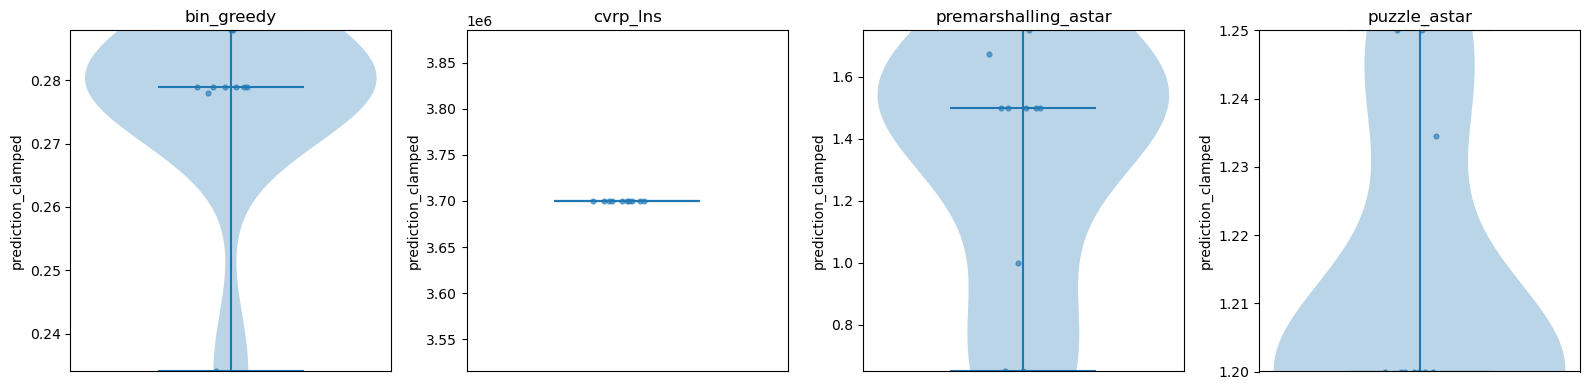

Plotted IDX = 0
bin_greedy: pop_4_op_e2_n19_251225_031500
cvrp_lns: pop_12_op_e1_n18_251227_060501
premarshalling_astar: pop_16_op_e1_n3_250819_105708
puzzle_astar: pop_16_op_m1_n17_251009_051647


In [28]:
# %% [code]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = OUT_CSV

FIG_W = 16
FIG_H = 4
Y_SCALE = "linear"          # "linear" oder "log"
SHOW_POINTS = True          # Punkte der Repeats zeigen?
PRED_COL = "prediction_clamped"  # oder "prediction_raw"

# Optional: feste Task-Reihenfolge (sonst wird automatisch genommen)
TASK_ORDER = None  # z.B. ["CVRP-LNS", "Premarshalling-A*", "Puzzle-A*", "BinGreedy"]

dfp = pd.read_csv(CSV_PATH)
dfp = dfp.dropna(subset=[PRED_COL]).copy()
dfp["heuristic_id"] = dfp["heuristic_id"].astype(str)
dfp["raw_app_type"] = dfp["raw_app_type"].astype(str)

tasks_available = list(dfp["raw_app_type"].unique())
tasks = [t for t in TASK_ORDER if t in tasks_available] if TASK_ORDER else tasks_available

# Heuristik-Auswahl: pro Task die 0-te Heuristik (in CSV-Reihenfolge)
IDX = 0
first_hid = (
    dfp.groupby("raw_app_type")["heuristic_id"]
       .apply(lambda s: s.iloc[IDX] if len(s) > IDX else s.iloc[-1])
       .to_dict()
)

fig, axes = plt.subplots(1, len(tasks), figsize=(FIG_W, FIG_H))
if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    hid = first_hid[task]
    d = dfp[(dfp["raw_app_type"] == task) & (dfp["heuristic_id"] == hid)]

    preds = d[PRED_COL].values

    # Violin ONLY (blau ist default bei matplotlib)
    ax.violinplot(preds, showmeans=False, showmedians=True)

    if SHOW_POINTS:
        rng = np.random.default_rng(42)
        jitter = rng.normal(0, 0.03, size=len(preds))
        ax.scatter(np.full(len(preds), 1) + jitter, preds, s=12, alpha=0.6)

    ax.set_title(task)
    ax.set_xticks([])
    ax.set_ylabel(PRED_COL)
    ax.set_yscale(Y_SCALE)
    ax.autoscale(enable=True, axis="y", tight=True)

plt.tight_layout()
plt.show()

print("Plotted IDX =", IDX)
for t in tasks:
    print(f"{t}: {first_hid[t]}")


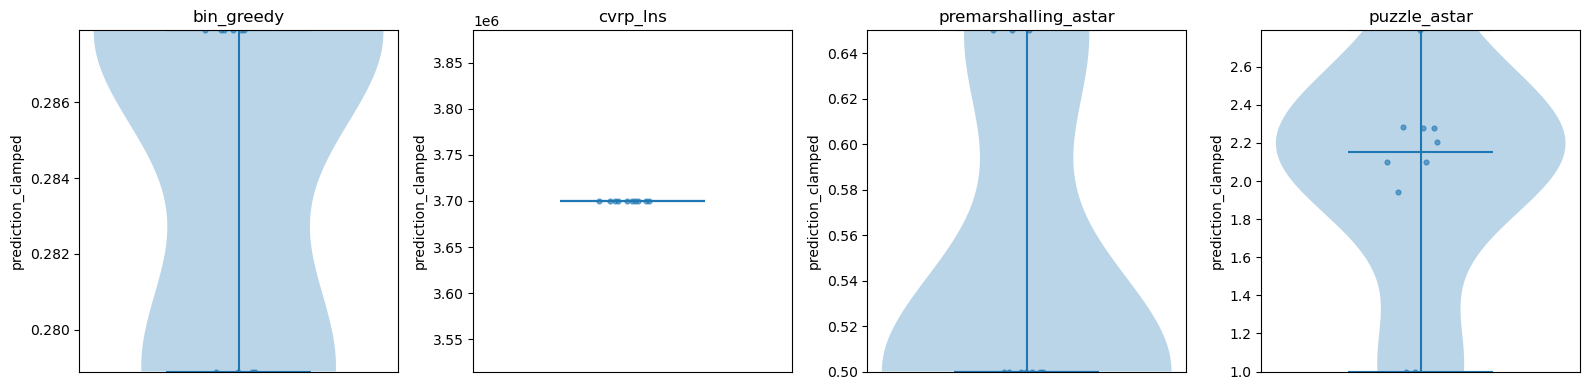

Plotted IDX = 20
bin_greedy: pop_10_op_e1_n11_251224_163329
cvrp_lns: pop_10_op_e2_n13_251227_001656
premarshalling_astar: pop_15_op_m1_n4_250821_235057
puzzle_astar: pop_5_op_m1_n8_251005_041917
------------------------------------------------------------


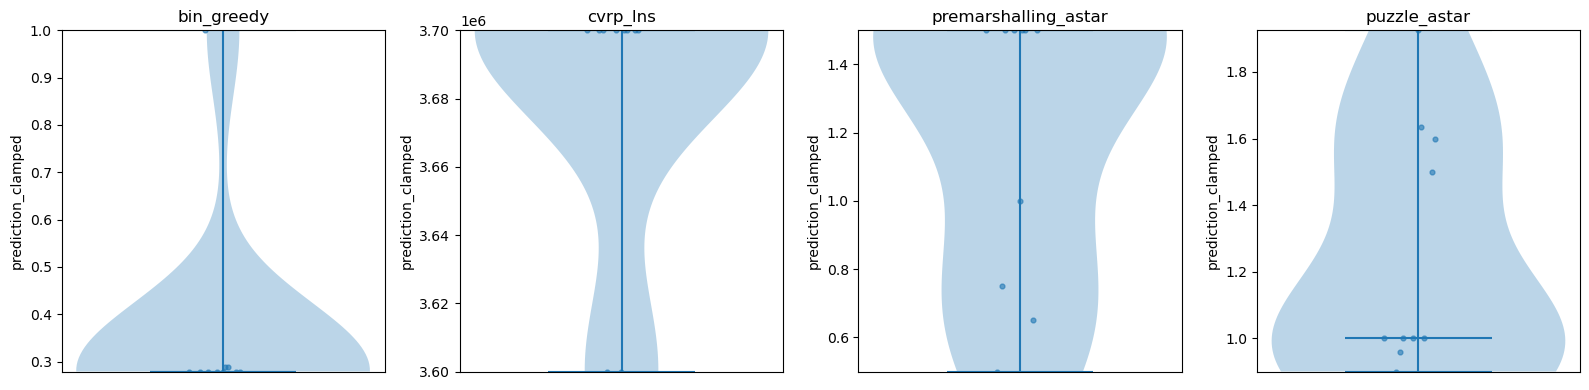

Plotted IDX = 30
bin_greedy: pop_8_op_e1_n2_251224_160509
cvrp_lns: pop_17_op_m1_n8_251228_005726
premarshalling_astar: pop_11_op_m1_n4_250821_204759
puzzle_astar: pop_5_op_e2_n9_251005_035236
------------------------------------------------------------


In [29]:
# %% [code]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = OUT_CSV

FIG_W = 16
FIG_H = 4
Y_SCALE = "linear"
SHOW_POINTS = True
PRED_COL = "prediction_clamped"  # oder "prediction_raw"

TASK_ORDER = None  # z.B. ["CVRP-LNS", "Premarshalling-A*", "Puzzle-A*", "BinGreedy"]
IDX_LIST = [20, 30]  # <-- hier sind deine "weiteren zwei" Heuristiken pro Task

dfp = pd.read_csv(CSV_PATH)
dfp = dfp.dropna(subset=[PRED_COL]).copy()
dfp["heuristic_id"] = dfp["heuristic_id"].astype(str)
dfp["raw_app_type"] = dfp["raw_app_type"].astype(str)

tasks_available = list(dfp["raw_app_type"].unique())
tasks = [t for t in TASK_ORDER if t in tasks_available] if TASK_ORDER else tasks_available

for IDX in IDX_LIST:
    # Heuristik-Auswahl: pro Task die IDX-te Heuristik (fallback auf letzte, falls zu wenig)
    picked_hid = (
        dfp.groupby("raw_app_type")["heuristic_id"]
           .apply(lambda s: s.iloc[IDX] if len(s) > IDX else s.iloc[-1])
           .to_dict()
    )

    fig, axes = plt.subplots(1, len(tasks), figsize=(FIG_W, FIG_H))
    if len(tasks) == 1:
        axes = [axes]

    for ax, task in zip(axes, tasks):
        hid = picked_hid[task]
        d = dfp[(dfp["raw_app_type"] == task) & (dfp["heuristic_id"] == hid)]
        preds = d[PRED_COL].values

        ax.violinplot(preds, showmeans=False, showmedians=True)

        if SHOW_POINTS:
            rng = np.random.default_rng(42)
            jitter = rng.normal(0, 0.03, size=len(preds))
            ax.scatter(np.full(len(preds), 1) + jitter, preds, s=12, alpha=0.6)

        ax.set_title(task)
        ax.set_xticks([])
        ax.set_ylabel(PRED_COL)
        ax.set_yscale(Y_SCALE)
        ax.autoscale(enable=True, axis="y", tight=True)

    plt.tight_layout()
    plt.show()

    print("Plotted IDX =", IDX)
    for t in tasks:
        print(f"{t}: {picked_hid[t]}")
    print("-" * 60)
